In [ ]:
# 3.i / 3.ii (Lexicons studied/used in code: VADER + TextBlob)
import os
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('vader_lexicon')
# 3.i (VADER)
from nltk.sentiment import SentimentIntensityAnalyzer
# 3.ii (TextBlob)
from textblob import TextBlob
# 7 (accuracy/precision/recall/F1 + confusion matrix)
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\kulis\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# 10.
# =========================
# CONFIG (AMAZON_FASHION_5.json.gz)
# =========================

DATASET_PATH = "AMAZON_FASHION_5.json.gz"

OUTPUT_DIR = "phase1_outputs"

RANDOM_SEED = 42
SAMPLE_SIZE = 1000

# When True the notebook will both save and display figures during execution.
SHOW_PLOTS = True

In [3]:
# =========================
# UTILS
# =========================
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

In [ ]:
# 10 (submit documented code: load and normalize required dataset)
def load_reviews_dataset(path: str) -> pd.DataFrame:
    """
    Loads the AMAZON_FASHION_5 review file and normalizes key columns so the
    rest of the Phase 1 workflow can stay close to the original notebook.
    """
    df = pd.read_json(path, lines=True, compression="gzip")
    df = df.rename(
        columns={
            "overall": "ratings",
            "reviewText": "review_text",
            "reviewerID": "reviewer_id",
        }
    )
    return df.copy()

In [ ]:
# 2.b (choose the appropriate columns for the sentiment analyzer)
def to_text_maybe_list(x) -> str:
    """
    Some datasets store tokens like: "['good','shirt']" as a string.
    Convert that into: "good shirt".
    """
    if pd.isna(x):
        return ""

    s = str(x).strip()
    if s.startswith("[") and s.endswith("]"):
        try:
            lst = ast.literal_eval(s)
            if isinstance(lst, list):
                return " ".join(str(t) for t in lst).strip()
        except Exception:
            pass

    return s

In [ ]:
# 2.b (combine chosen text columns into one sentiment input)
def combine_summary_review(summary_text: str, review_text: str) -> str:
    summary_text = (summary_text or "").strip()
    review_text = (review_text or "").strip()
    if summary_text and review_text:
        return f"{summary_text}. {review_text}"
    return summary_text or review_text

In [ ]:
# 2.a (label data based on the rating of the product)
def label_from_rating(r):
    """
    Label rules required by the Phase 1 rubric.
    """
    try:
        r = float(r)
    except Exception:
        return np.nan

    # 2.a.i. (Ratings 4,5 => Positive)
    if r >= 4:
        return "Positive"
    # 2.a.ii. (Rating 3 => Neutral)
    elif r == 3:
        return "Neutral"
    # 2.a.iii. (Ratings 1,2 => Negative)
    elif r <= 2:
        return "Negative"
    return np.nan

In [ ]:
# 4 (VADER preprocessing based on the selected lexicon characteristics)
def preprocess_for_vader(text: str) -> str:
    # 4 (keep punctuation/emphasis, only remove URLs and normalize spaces)
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
# 4 (TextBlob preprocessing based on the selected lexicon characteristics)
def preprocess_for_textblob(text: str) -> str:
    # 4 (normalize lowercase text, remove URLs, and remove most non-letters)
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
# 1.a / 1.b / 1.e (plots used for dataset exploration)
def save_hist(values, title, xlabel, filename, bins=50):
    plt.figure()
    plt.hist(pd.Series(values).dropna(), bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

In [ ]:
# 1.c / 1.d / 1.e (boxplots used for dataset exploration)
def save_boxplot(values, title, ylabel, filename):
    plt.figure()
    plt.boxplot(pd.Series(values).dropna(), vert=True)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

In [ ]:
# 7 (confusion matrix outputs for validation)
def save_confusion(cm, labels, title, filename):
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=30)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

In [ ]:
# 7 (accuracy/precision/recall/F1 + confusion matrix)
def evaluate(y_true, y_pred, labels=("Negative", "Neutral", "Positive")):
    acc = accuracy_score(y_true, y_pred)
    pr_w, rc_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(labels), average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(labels))
    return acc, pr_w, rc_w, f1_w, cm

In [ ]:
# =========================
# MODELS (Lexicon)
# =========================
# 6.a / 3.i (VADER lexicon model)
def vader_predict(texts: pd.Series) -> pd.Series:
    analyzer = SentimentIntensityAnalyzer()
    preds = []
    for t in texts:
        c = analyzer.polarity_scores(t)["compound"]
        if c >= 0.05:
            preds.append("Positive")
        elif c <= -0.05:
            preds.append("Negative")
        else:
            preds.append("Neutral")
    return pd.Series(preds, index=texts.index)

In [ ]:
# 6.a / 3.ii (TextBlob lexicon model)
def textblob_predict(texts: pd.Series) -> pd.Series:
    preds = []
    for t in texts:
        pol = TextBlob(t).sentiment.polarity
        if pol > 0.1:
            preds.append("Positive")
        elif pol < -0.1:
            preds.append("Negative")
        else:
            preds.append("Neutral")
    return pd.Series(preds, index=texts.index)

In [ ]:
# =========================
# MAIN
# =========================

# Setup output directory
# 10 (submit documented code)
ensure_dir(OUTPUT_DIR)

In [ ]:
# -------------------------
# Load AMAZON_FASHION_5.json.gz
# -------------------------
# 10 (submit documented code)
df_train = load_reviews_dataset(DATASET_PATH)

print("Dataset shape:", df_train.shape)
print("Available columns:", sorted(df_train.columns))

Dataset shape: (3176, 12)
Available columns: ['asin', 'image', 'ratings', 'reviewTime', 'review_text', 'reviewerName', 'reviewer_id', 'style', 'summary', 'unixReviewTime', 'verified', 'vote']


## Phase 1 Dataset Choice
This notebook now uses only `AMAZON_FASHION_5.json.gz`, which is the required Phase 1 source file.
The code normalizes the dataset schema once after loading so the rest of the analysis can stay close to the original workflow.

Rows before rating cleanup: 3176
Rows after rating cleanup : 3176
Average rating: 4.404
Median rating : 5.0
Unique users  : 406
Unique products: 31
Missing review_text rows: 16


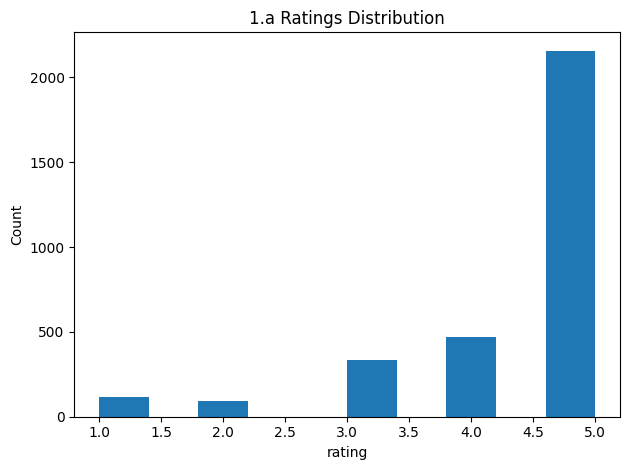

In [ ]:
# -------------------------
# Dataset data exploration
# -------------------------
# 1.a (counts and averages)
df_train["ratings"] = pd.to_numeric(df_train["ratings"], errors="coerce")
n_before = len(df_train)
df_train = df_train.dropna(subset=["ratings"]).copy()
n_after = len(df_train)

avg_rating = df_train["ratings"].mean()
med_rating = df_train["ratings"].median()
n_users = df_train["reviewer_id"].nunique() if "reviewer_id" in df_train.columns else None
n_products = df_train["asin"].nunique() if "asin" in df_train.columns else None
missing_review_text = int(df_train["review_text"].isna().sum()) if "review_text" in df_train.columns else None

print("Rows before rating cleanup:", n_before)
print("Rows after rating cleanup :", n_after)
print("Average rating:", round(avg_rating, 3))
print("Median rating :", med_rating)
print("Unique users  :", n_users)
print("Unique products:", n_products)
print("Missing review_text rows:", missing_review_text)

save_hist(df_train["ratings"], "1.a Ratings Distribution", "rating", "1a_ratings_hist.png", bins=10)

Products with at least one review: 31
Average reviews per product: 102.452


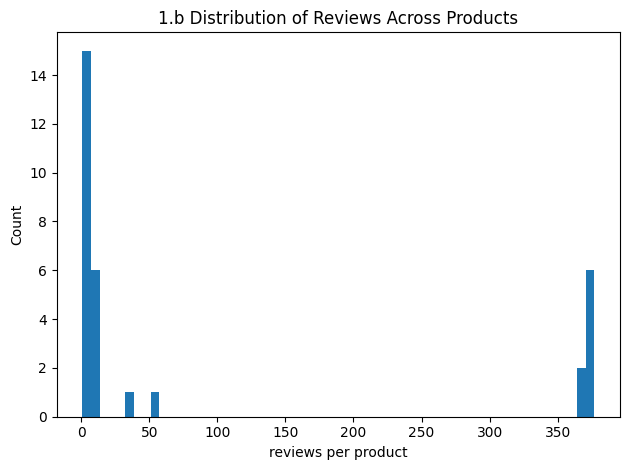

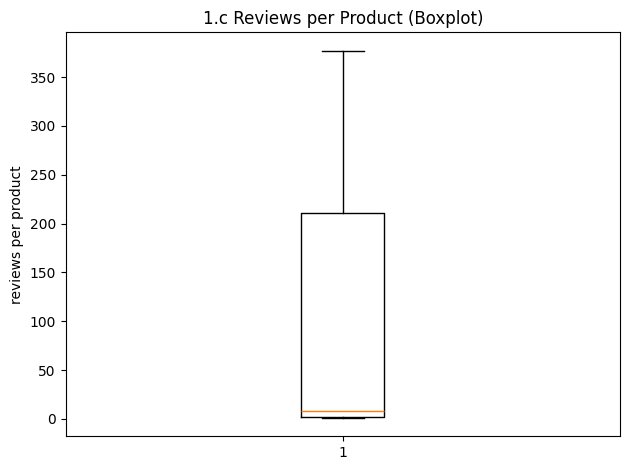

Users with at least one review: 406
Average reviews per user: 7.823


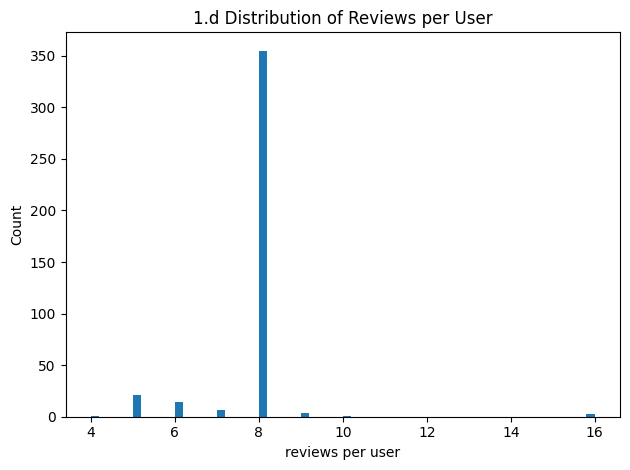

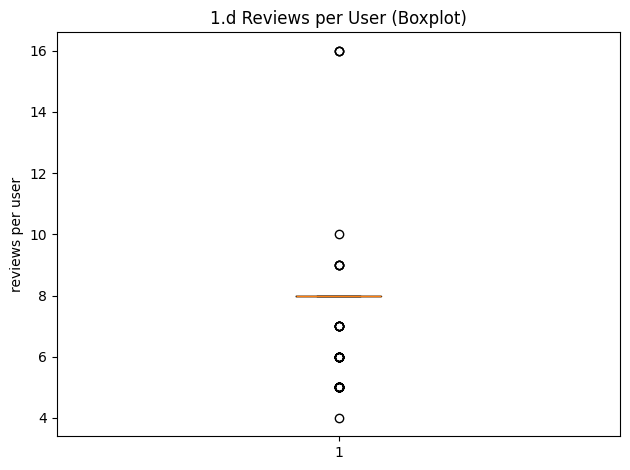

In [ ]:
# Reviews per product / user

if "asin" in df_train.columns:
    # 1.b.
    reviews_per_product = df_train["asin"].value_counts()
    print("Products with at least one review:", len(reviews_per_product))
    print("Average reviews per product:", round(reviews_per_product.mean(), 3))
    save_hist(
        reviews_per_product.values,
        "1.b Distribution of Reviews Across Products",
        "reviews per product",
        "1b_reviews_across_products_hist.png",
        bins=60
    )
    # 1.c.
    save_boxplot(
        reviews_per_product.values,
        "1.c Reviews per Product (Boxplot)",
        "reviews per product",
        "1c_reviews_per_product_boxplot.png"
    )

if "reviewer_id" in df_train.columns:
    # 1.d.
    reviews_per_user = df_train["reviewer_id"].value_counts()
    print("Users with at least one review:", len(reviews_per_user))
    print("Average reviews per user:", round(reviews_per_user.mean(), 3))
    save_hist(
        reviews_per_user.values,
        "1.d Distribution of Reviews per User",
        "reviews per user",
        "1d_reviews_per_user_hist.png",
        bins=60
    )
    save_boxplot(
        reviews_per_user.values,
        "1.d Reviews per User (Boxplot)",
        "reviews per user",
        "1d_reviews_per_user_boxplot.png"
    )

Rows with empty combined text: 0


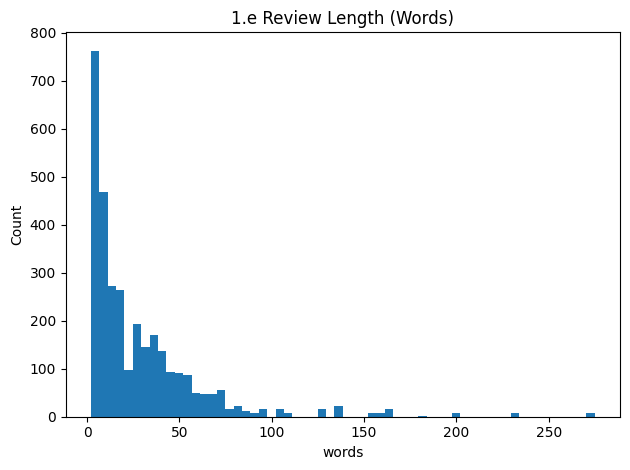

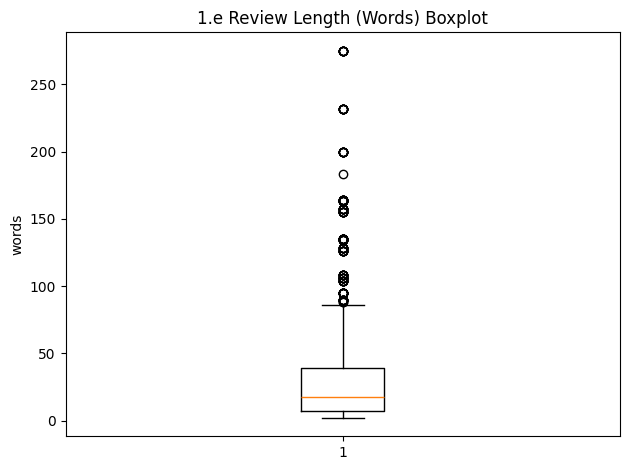

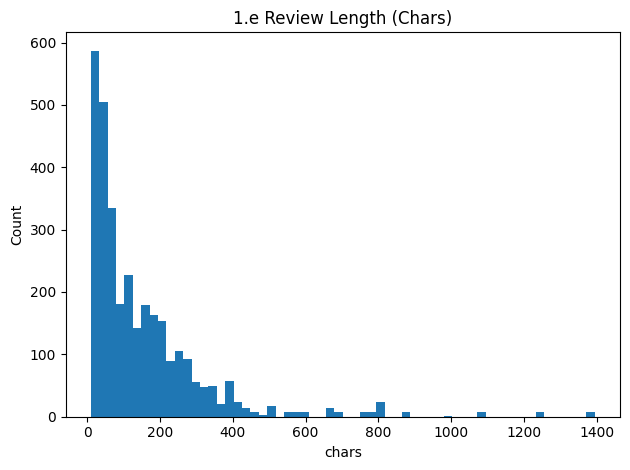

In [ ]:
# Text preparation + length analysis
# 2.b.
df_train["review_text_str"] = df_train["review_text"].apply(to_text_maybe_list)
df_train["summary_str"] = df_train["summary"].apply(to_text_maybe_list)
df_train["full_text"] = df_train.apply(
    lambda r: combine_summary_review(r["summary_str"], r["review_text_str"]),
    axis=1
)
df_train["full_text"] = df_train["full_text"].fillna("").astype(str)

print("Rows with empty combined text:", int((df_train["full_text"].str.len() == 0).sum()))

# 1.e.
df_train["len_words"] = df_train["full_text"].apply(lambda x: len(str(x).split()))
df_train["len_chars"] = df_train["full_text"].apply(lambda x: len(str(x)))

save_hist(df_train["len_words"], "1.e Review Length (Words)", "words", "1e_len_words_hist.png", bins=60)
save_boxplot(df_train["len_words"], "1.e Review Length (Words) Boxplot", "words", "1e_len_words_boxplot.png")
save_hist(df_train["len_chars"], "1.e Review Length (Chars)", "chars", "1e_len_chars_hist.png", bins=60)

## Text Columns Chosen
For sentiment analysis, the notebook uses `summary` and `reviewText` together.
`summary` captures the short headline sentiment, while `reviewText` carries the detailed opinion. Combining them preserves more sentiment signal than using either field alone.

In [ ]:
# Outlier detection (IQR)
# 2.c.
q1 = df_train["len_words"].quantile(0.25)
q3 = df_train["len_words"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (df_train["len_words"] < lower) | (df_train["len_words"] > upper)
outlier_count = int(outlier_mask.sum())

# 1.f.
print("Word-length outliers:", outlier_count)
print("IQR lower bound:", round(lower, 3))
print("IQR upper bound:", round(upper, 3))

df_train.loc[outlier_mask, ["ratings", "len_words", "len_chars", "full_text"]] \
    .head(15) \
    .to_csv(os.path.join(OUTPUT_DIR, "1f_length_outlier_examples.csv"), index=False)

Word-length outliers: 146
IQR lower bound: -41.0
IQR upper bound: 87.0


In [ ]:
# 1.g.
dup_full_text = df_train.duplicated(subset=["full_text"]).sum()
dup_summary_review = df_train.duplicated(subset=["summary_str", "review_text_str"]).sum()

print("Duplicate full_text:", dup_full_text)
print("Duplicate summary+review:", dup_summary_review)
print("Duplicate full_text percentage:", round(100 * dup_full_text / len(df_train), 3))

Duplicate full_text: 2733
Duplicate summary+review: 2733
Duplicate full_text percentage: 86.052


In [ ]:
# Labeling
# 2.a.i / 2.a.ii / 2.a.iii (apply rating-based sentiment labels)
df_train["label"] = df_train["ratings"].apply(label_from_rating)
df_train = df_train.dropna(subset=["label"]).copy()

print("Label distribution:")
print(df_train["label"].value_counts())

Label distribution:
label
Positive    2629
Neutral      337
Negative     210
Name: count, dtype: int64


In [ ]:
# Model-specific preprocessing
# 4 (apply model-specific preprocessing for each selected lexicon)
df_train["text_vader"] = df_train["full_text"].apply(preprocess_for_vader)
df_train["text_blob"]  = df_train["full_text"].apply(preprocess_for_textblob)

## Lexicon And Preprocessing Justification
The notebook keeps VADER and TextBlob as the two Phase 1 lexicon models.
VADER is designed for short opinion-rich text and benefits from punctuation and emphasis, so its preprocessing is intentionally light. TextBlob uses polarity over cleaned text, so the notebook lowercases and removes most non-letter noise before scoring. SentiWordNet was not chosen here because it requires a heavier word-sense pipeline, which is harder to keep consistent for a compact Phase 1 baseline.

In [ ]:
# Sampling
# 5 (randomly select 1000 reviews from your dataset)
df_s = df_train.sample(
    n=min(SAMPLE_SIZE, len(df_train)),
    random_state=RANDOM_SEED
).copy()

print("Sample size:", len(df_s))
print("Sample label distribution:")
print(df_s["label"].value_counts())

y_true = df_s["label"].astype(str)

Sample size: 1000
Sample label distribution:
label
Positive    837
Neutral     101
Negative     62
Name: count, dtype: int64


In [ ]:
# Predictions
# 6.a (build two lexicon-based sentiment analysis models)
y_vader = vader_predict(df_s["text_vader"])
y_blob  = textblob_predict(df_s["text_blob"])

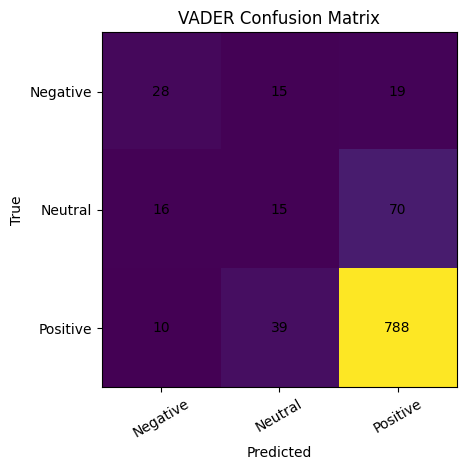

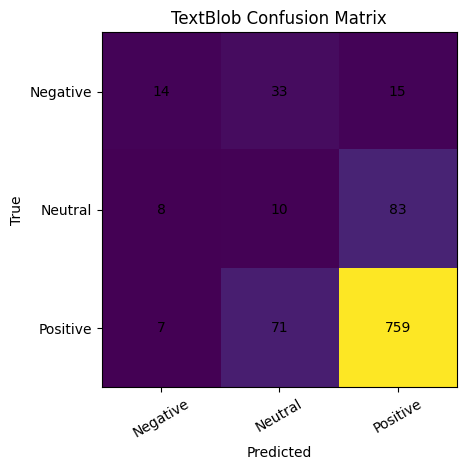

      Model  Accuracy  Precision_w  Recall_w      F1_w
0     VADER     0.831     0.806164     0.831  0.817365
1  TextBlob     0.783     0.780078     0.783  0.778511


In [ ]:
# Evaluation
# 7 (accuracy/precision/recall/F1 + confusion matrix)
labels_order = ("Negative", "Neutral", "Positive")

acc_v, pr_v, rc_v, f1_v, cm_v = evaluate(y_true, y_vader, labels=labels_order)
acc_b, pr_b, rc_b, f1_b, cm_b = evaluate(y_true, y_blob, labels=labels_order)

save_confusion(cm_v, labels_order, "VADER Confusion Matrix", "7_cm_vader.png")
save_confusion(cm_b, labels_order, "TextBlob Confusion Matrix", "7_cm_textblob.png")

comparison = pd.DataFrame([
    {"Model": "VADER", "Accuracy": acc_v, "Precision_w": pr_v, "Recall_w": rc_v, "F1_w": f1_v},
    {"Model": "TextBlob", "Accuracy": acc_b, "Precision_w": pr_b, "Recall_w": rc_b, "F1_w": f1_b},
])
comparison = comparison.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

comparison.to_csv(os.path.join(OUTPUT_DIR, "7_lexicon_comparison_table.csv"), index=False)

print(comparison)